In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_jobs = pd.read_csv(
    r"C:\Projects\JobPulse\data\raw\linkedin_data\job_postings.csv"
)

In [3]:
df_jobs.head()

,job_id,company_id,title,description,max_salary,med_salary,min_salary,pay_period,formatted_work_type,location,...,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type
0,85008768,NaN,Licensed Insurance Agent,While many industries were hurt by the last fe...,52000.0,NaN,45760.0,YEARLY,Full-time,"Chico, CA",...,1.710000e+12,NaN,NaN,NaN,1.690000e+12,NaN,1,FULL_TIME,USD,BASE_SALARY
1,133114754,77766802.0,Sales Manager,Are you a dynamic and creative marketing profe...,NaN,NaN,NaN,NaN,Full-time,"Santa Clarita, CA",...,1.700000e+12,NaN,NaN,NaN,1.690000e+12,NaN,0,FULL_TIME,NaN,NaN
2,133196985,1089558.0,Model Risk Auditor,Join Us as a Model Risk Auditor – Showcase You...,NaN,NaN,NaN,NaN,Contract,"New York, NY",...,1.700000e+12,NaN,NaN,NaN,1.690000e+12,NaN,0,CONTRACT,NaN,NaN
3,381055942,96654609.0,Business Manager,Business ManagerFirst Baptist Church ForneyFor...,NaN,NaN,NaN,NaN,Full-time,"Forney, TX",...,1.700000e+12,NaN,NaN,NaN,1.690000e+12,NaN,0,FULL_TIME,NaN,NaN
4,529257371,1244539.0,NY Studio Assistant,YOU COULD BE ONE OF THE MAGIC MAKERS\nKen Fulk...,NaN,NaN,NaN,NaN,Full-time,"New York, NY",...,1.710000e+12,NaN,NaN,NaN,1.690000e+12,NaN,1,FULL_TIME,NaN,NaN


In [4]:
df_jobs.info()

<class 'pandas.DataFrame'>
RangeIndex: 15886 entries, 0 to 15885
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_id                      15886 non-null  int64  
 1   company_id                  15520 non-null  float64
 2   title                       15886 non-null  str    
 3   description                 15885 non-null  str    
 4   max_salary                  5521 non-null   float64
 5   med_salary                  981 non-null    float64
 6   min_salary                  5521 non-null   float64
 7   pay_period                  6502 non-null   str    
 8   formatted_work_type         15886 non-null  str    
 9   location                    15886 non-null  str    
 10  applies                     8700 non-null   float64
 11  original_listed_time        15886 non-null  float64
 12  remote_allowed              2340 non-null   float64
 13  views                       13123 non-null

In [5]:
df_jobs.isnull().sum()

job_id                            0
company_id                      366
title                             0
description                       1
max_salary                    10365
med_salary                    14905
min_salary                    10365
pay_period                     9384
formatted_work_type               0
location                          0
applies                        7186
original_listed_time              0
remote_allowed                13546
views                          2763
job_posting_url                   0
application_url                6091
application_type                  0
expiry                            0
closed_time                   14958
formatted_experience_level     4902
skills_desc                   15742
listed_time                       0
posting_domain                 6842
sponsored                         0
work_type                         0
currency                       9384
compensation_type              9384
dtype: int64

In [6]:
df_jobs.columns

Index(['job_id', 'company_id', 'title', 'description', 'max_salary',
       'med_salary', 'min_salary', 'pay_period', 'formatted_work_type',
       'location', 'applies', 'original_listed_time', 'remote_allowed',
       'views', 'job_posting_url', 'application_url', 'application_type',
       'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc',
       'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency',
       'compensation_type'],
      dtype='str')

In [7]:
df_jobs.shape


(15886, 27)

In [8]:
df_jobs.duplicated().sum()

np.int64(0)

In [10]:
df_jobs.columns

Index(['job_id', 'company_id', 'title', 'description', 'max_salary',
       'med_salary', 'min_salary', 'pay_period', 'formatted_work_type',
       'location', 'applies', 'original_listed_time', 'remote_allowed',
       'views', 'job_posting_url', 'application_url', 'application_type',
       'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc',
       'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency',
       'compensation_type'],
      dtype='str')

In [11]:
df_jobs.isnull().sum().sort_values(ascending=False)

skills_desc                   15742
closed_time                   14958
med_salary                    14905
remote_allowed                13546
max_salary                    10365
min_salary                    10365
pay_period                     9384
compensation_type              9384
currency                       9384
applies                        7186
posting_domain                 6842
application_url                6091
formatted_experience_level     4902
views                          2763
company_id                      366
description                       1
formatted_work_type               0
job_id                            0
title                             0
location                          0
application_type                  0
original_listed_time              0
job_posting_url                   0
expiry                            0
listed_time                       0
work_type                         0
sponsored                         0
dtype: int64

In [12]:
df_jobs = df_jobs.drop_duplicates()

In [13]:
df_jobs.columns = (
    df_jobs.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

In [14]:
df_jobs = df_jobs[
    [
        "job_id",
        "company_id",
        "title",
        "description",
        "max_salary",
        "med_salary",
        "min_salary",
        "formatted_work_type",
        "location",
        "formatted_experience_level",
        "work_type",
        "currency",
        "compensation_type"
    ]
]

In [15]:
df_jobs[["max_salary", "med_salary", "min_salary"]].isnull().sum()

max_salary    10365
med_salary    14905
min_salary    10365
dtype: int64

In [16]:
df_jobs["med_salary"] = df_jobs["med_salary"].fillna(
    df_jobs["max_salary"]
)

In [17]:
df_jobs["title"].value_counts().head(20)

title
Sales Director [Owner/Operator]                         83
Sales Associate                                         64
Retail Sales Associate                                  60
Sales Director {Owner/Operator}                         54
Administrative Assistant                                40
Project Manager                                         40
Staff Accountant                                        40
Customer Service Representative                         39
Call Center Support Rep                                 38
Executive Assistant                                     37
Senior Accountant                                       37
Scoring Content Specialist                              36
Sales Manager                                           34
Account Executive                                       34
Controller                                              29
Block Advisor - Remote Tax Professional                 29
General Superintendent, Mission Critical - Traveli

In [18]:
df_jobs["location"].value_counts().head(20)

location
United States                      1133
New York, NY                        398
Chicago, IL                         267
Houston, TX                         243
Atlanta, GA                         207
Los Angeles, CA                     188
Dallas, TX                          182
Austin, TX                          168
Boston, MA                          147
San Diego, CA                       137
New York City Metropolitan Area     136
Seattle, WA                         133
Phoenix, AZ                         132
San Francisco, CA                   130
Charlotte, NC                       125
Denver, CO                          117
Washington, DC                      109
Nashville, TN                        99
Philadelphia, PA                     90
Las Vegas, NV                        84
Name: count, dtype: int64

In [19]:
df_jobs["formatted_work_type"].value_counts()

formatted_work_type
Full-time     12844
Contract       1739
Part-time      1010
Temporary       121
Internship      111
Other            53
Volunteer         8
Name: count, dtype: int64

In [20]:
df_jobs["formatted_experience_level"].value_counts()

formatted_experience_level
Mid-Senior level    5083
Entry level         3694
Associate           1220
Director             687
Internship           166
Executive            134
Name: count, dtype: int64

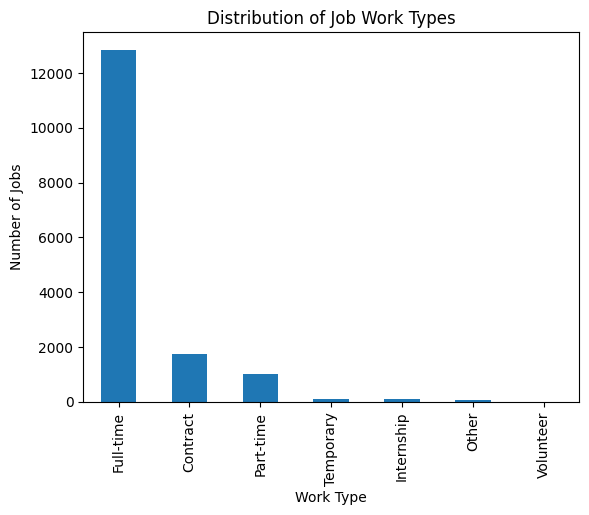

In [24]:
df_jobs["formatted_work_type"].value_counts().plot(kind="bar")

plt.title("Distribution of Job Work Types")
plt.xlabel("Work Type")
plt.ylabel("Number of Jobs")
plt.show()

In [26]:
df_jobs["max_salary"] = df_jobs["max_salary"].fillna(0)

df_jobs["med_salary"] = df_jobs["med_salary"].fillna(0)

df_jobs["min_salary"] = df_jobs["min_salary"].fillna(0)

In [27]:
df_jobs["formatted_experience_level"] = (
    df_jobs["formatted_experience_level"]
    .fillna("Not Specified")
)

In [28]:
df_jobs = df_jobs.dropna(subset=["description"])

In [29]:
df_jobs["location"] = (
    df_jobs["location"]
    .fillna("Unknown")
)

In [30]:
df_jobs["formatted_work_type"] = (
    df_jobs["formatted_work_type"]
    .fillna("Other")
)

In [31]:
df_jobs["currency"] = (
    df_jobs["currency"]
    .fillna("Unknown")
)

In [32]:
df_jobs.isnull().sum()

job_id                           0
company_id                     366
title                            0
description                      0
max_salary                       0
med_salary                       0
min_salary                       0
formatted_work_type              0
location                         0
formatted_experience_level       0
work_type                        0
currency                         0
compensation_type             9383
dtype: int64

In [33]:
df_jobs["company_id"] = df_jobs["company_id"].fillna(0)

In [34]:
df_jobs["compensation_type"] = (
    df_jobs["compensation_type"]
    .fillna("Not Specified")
)

In [35]:
df_jobs.to_csv(
    r"C:\Projects\JobPulse\data\cleaned\cleaned_job_postings.csv",
    index=False
)